# JK Covariance testing tutorial

This code demonstrates the process of performing a Jackknife covariance matrix testing with the Takahashi simulations.

* The measurement code and plot-making in this tutorial are configured with a configuration yaml file. The default configuration file is configs/t19lite.yml
* It will plot the measured lensing data vectors, and compare the diagnal terms of the JK covariance matrix with simulation variations.

Contributors: Yuanyuan Zhang, Camille Avestruz


## Running the measurement code

This section provides the example for running the measurement code on Takahashi simulations. 
* The measurement is done by running the compute_treecorr_cov.py code. It will produce gt profile measurements for clusters in select redshift and mass ranges, assuming different survey areas (nsky), and perform jackknife sampling (dividing each survey into a few patches)
* The measurements are configured with a yaml file. By default the measurement code uses configs/t19lite.yml
* Note that the running can take a long time (~ hours) if looping through tests of different sky areas.
* The output from the measurement code are saved into an output folder specificed in the yaml configuration file (by default the `measurements` folder). There will be measurement per jaccknife sample, per survey and per simulation.


In [7]:
## this line runs the measurement code with a configuration file. 
!python compute_treecorr_cov_wrandoms.py configs/test_treecorr.yml

Script name: compute_treecorr_cov_wrandoms.py
Arguments received:
  Argument 1: configs/test_treecorr.yml
Using config for:  Takahashi 2019
Info:  full-sky lensing maps and halos in lightcones
lightcones cover sky fraction of fsky=1/48, or 680 deg2,
480 realisations at z = 0.1, 0.3, 0.5, 0.7

{'simulation_name': 'Takahashi 2019', 'simulation_description': 'full-sky lensing maps and halos in lightcones\nlightcones cover sky fraction of fsky=1/48, or 680 deg2,\n480 realisations at z = 0.1, 0.3, 0.5, 0.7\n', 'inputfile': {'filename_sets': ['000'], 'halocat_filename_base': '/global/cfs/cdirs/lsst/groups/CL/takahashi_sims/catalogs/skyhalo_nres12r', 'halocat_filename_suffix': '.halo', 'shear_filename_base': '/global/cfs/cdirs/lsst/groups/CL/takahashi_sims/allskymaps/allskymap_nres12r', 'shear_filename_suffix': '.zs18.mag.dat'}, 'nsky': [2], 'run_treecorr': True, 'outputpath': 'test_treecorr_random/', 'tree_corr_angle': {'min': 0.1, 'max': 100.0, 'nbins': 50}, 'source_redshifts': {'min': 0.50

## Making the plots

For each survey area, the following section plot the measurements from the previous section, compare the data-based Jackknife covariance matrix to the variances of the measurements between different simulation realizations.

Below, we will first import the necessary libraries and modules, and configure the plots using the a configuration file, which should be the same one used for measurements.

In [1]:
## import libraries and modules
import numpy as np
import matplotlib.pyplot as plt
#import read_functions
from astropy.cosmology import FlatLambdaCDM
from astropy import units as u
from use_config import load_yaml_config
import os

## loading the yaml file that was used to generate measurements.
yaml_file = 'configs/t19lite.yml'
#yaml_file = 'configs/m14_4_15_z0_508_0_574.yml'
yaml_data = load_yaml_config(yaml_file)

## the simulation names and area of skies of the measurements
sim_names = yaml_data['inputfile']['filename_sets']
nskys = yaml_data['nsky']
output_path = yaml_data['outputpath']

Using config for:  Takahashi 2019
Info:  full-sky lensing maps and halos in lightcones
lightcones cover sky fraction of fsky=1/48, or 680 deg2,
480 realisations at z = 0.1, 0.3, 0.5, 0.7



### Plot comparisions between Jackknife-derived covariance matrix and the simulation variations.

The code below plots the gt measurements for clusters in the select mass/redshift range, as well as the covariances of these measurements, derived either with a data-based Jackknife sampling method, or by sampling measurements in different simulation variations.

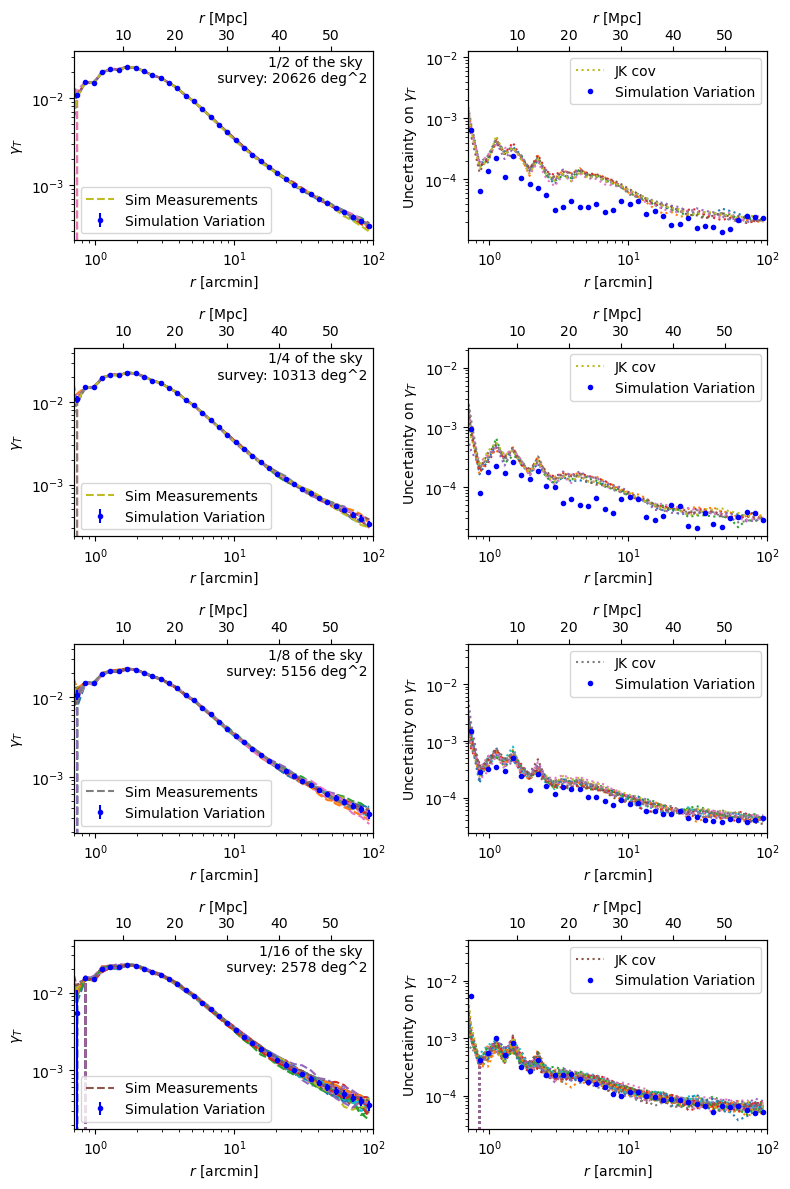

In [2]:
len_sim = len(sim_names)
len_skys=len(nskys)

fig, axs = plt.subplots(len_skys, 2, figsize=[8, 12])

for nn, nsky in enumerate(nskys):
    meas_rec=[]
    for ii in range(len_sim):
      #for jj in range(nsky):
      for jj in range(nsky):
          sim_name = sim_names[ii]
          file_name_ii_jj= output_path + 'datavector_'+sim_name+'_patchN%i_%i.txt'%(nsky, jj)
          if os.path.isfile(file_name_ii_jj):
              dat= np.genfromtxt(file_name_ii_jj)
              x_val = dat[:, 0]
              axs[nn, 0].plot(dat[:, 0], dat[:, 3], '--', label = 'Sim Measurements')
              meas_rec.append(dat[:, 3]) #the measurements recorded over different sims and in different patches are used to calculate a true covariance

          file_cov_ii_jj= output_path + 'cov_'+sim_name+'_patchN%i_%i.txt'%(nsky, jj)
          if os.path.isfile(file_cov_ii_jj):
              dat_cov= np.genfromtxt(file_cov_ii_jj)
              y_jk_err=np.sqrt(np.diag(dat_cov))
              axs[nn, 1].plot(x_val, y_jk_err, ':', label='JK cov ')
    
    if len(meas_rec) > 0:
        y_val=np.mean(meas_rec, axis=0)
        y_sim_err=np.std(meas_rec, axis=0)
        #print('shape', len_sim, nsky, np.shape(meas_rec), dat.shape)
        axs[nn, 0].errorbar(x_val, y_val, yerr=y_sim_err, fmt='b.', label='Simulation Variation')
        axs[nn, 1].errorbar(x_val, y_sim_err, fmt='b.', label='Simulation Variation')


        
    
    handles, labels = axs[nn, 0].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    #print(nn, nsky)
    axs[nn, 0].text(0.98, 0.98, '1/%i of the sky \n survey: %i deg^2'%(nsky, 41252.96125/nsky), \
         transform=axs[nn, 0].transAxes, verticalalignment='top', horizontalalignment='right')
    axs[nn, 0].legend(by_label.values(), by_label.keys())
    axs[nn, 0].set_xscale('log')
    axs[nn, 0].set_yscale('log')
    axs[nn, 0].set_xlim(0.7, 100)
    axs[nn, 0].set_xlabel(r'$r$ [arcmin]')
    axs[nn, 0].set_ylabel(r'$\gamma_T$')

    handles, labels = axs[nn, 1].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    axs[nn, 1].legend(by_label.values(), by_label.keys())
    axs[nn, 1].set_xscale('log')
    axs[nn, 1].set_yscale('log')
    axs[nn, 1].set_xlim(0.7, 100)
    axs[nn, 1].set_xlabel(r'$r$ [arcmin]')
    axs[nn, 1].set_ylabel(r'Uncertainty on $\gamma_T$')


    
    ## convert angular scale to physical scale
    # Define the cosmology
    cosmo = FlatLambdaCDM(H0=70.0, Om0=0.279) # Example values
    # Define the redshift and angle
    z_cl=0.53 ## need to change depending on the cluster sample
    d_A = cosmo.comoving_distance(z_cl)
    
    ax2 = axs[nn, 0].twiny()
    mn, mx = axs[nn, 0].get_xlim()
    ax2.set_xlim( (mn* u.arcmin).to(u.radian).value*d_A.value, (mx* u.arcmin).to(u.radian).value*d_A.value)
    ax2.set_xlabel(r'$r$ [Mpc]')

    ax3 = axs[nn, 1].twiny()
    mn, mx = axs[nn, 1].get_xlim()
    ax3.set_xlim( (mn* u.arcmin).to(u.radian).value*d_A.value, (mx* u.arcmin).to(u.radian).value*d_A.value)
    ax3.set_xlabel(r'$r$ [Mpc]')
    
    
plt.tight_layout()

Plotting the errorbar from covariance and simulation variation

### Comparing eigen values and eigen vectors to compare off-diagonal items of the matrix

The code below plots the gt measurements for clusters in the select mass/redshift range, as well as the eigen values and vectors, derived either with a data-based Jackknife sampling method, or by sampling measurements in different simulation variations. This comparison will examine the off-diagonal items of the covariance matrix and follows the method in arXiv:2109.07071.

/tmp/ipykernel_875690/3843663020.py:13: RuntimeWarning: invalid value encountered in divide
  correlation = covariance / outer_v
/global/common/software/lsst/gitlab/desc-python-prod/2026-06-12-57-22/py/envs/desc-python/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/global/common/software/lsst/gitlab/desc-python-prod/2026-06-12-57-22/py/envs/desc-python/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


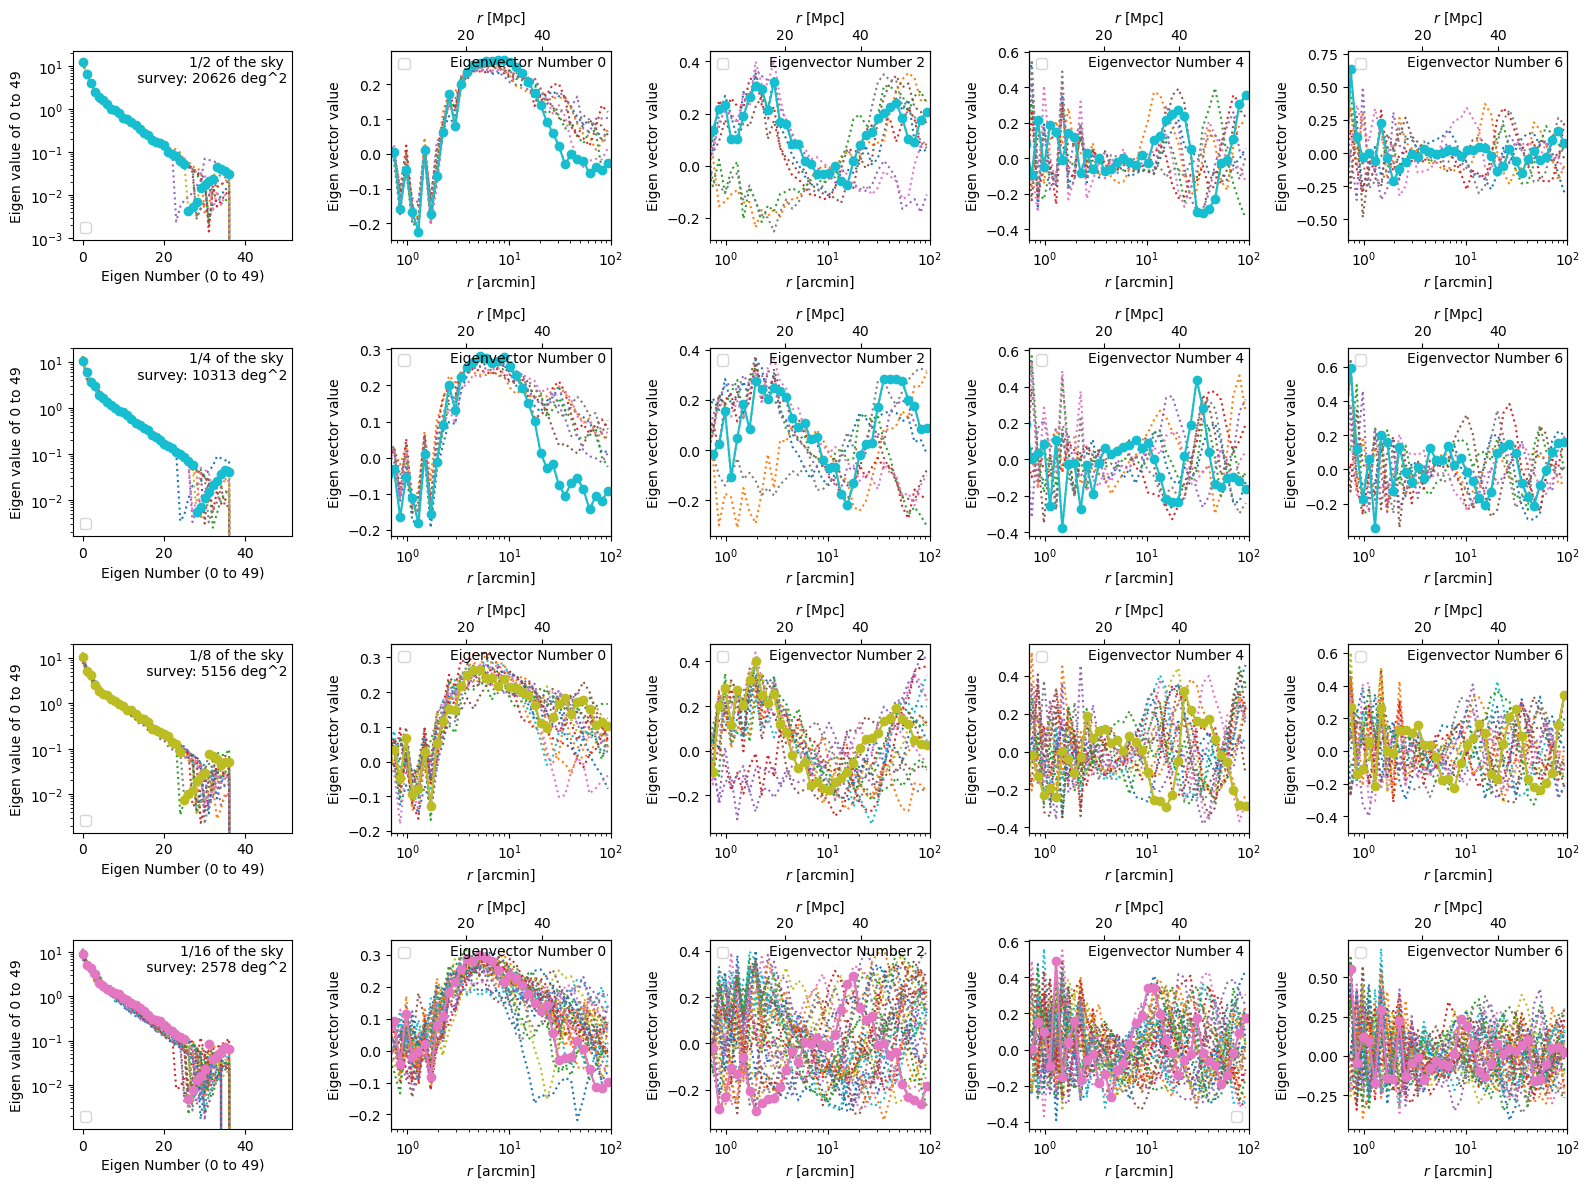

In [3]:
from numpy import linalg as LA
import matplotlib as mpl

len_sim = len(sim_names)
len_skys=len(nskys)
cmap=mpl.colormaps['hsv']

fig, axs = plt.subplots(len_skys, 5, figsize=[16, 12])

def correlation_from_covariance(covariance):
    v = np.sqrt(np.diag(covariance))
    outer_v = np.outer(v, v)
    correlation = covariance / outer_v
    correlation[covariance == 0] = 0
    return correlation

for nn, nsky in enumerate(nskys):
    meas_rec=[]
    for ii in range(len_sim):
      #for jj in range(nsky):
      for jj in range(nsky):
          sim_name = sim_names[ii]
          file_name_ii_jj= output_path + 'datavector_'+sim_name+'_patchN%i_%i.txt'%(nsky, jj)
          if os.path.isfile(file_name_ii_jj):
              dat= np.genfromtxt(file_name_ii_jj)
              x_val = dat[:, 0]
              meas_rec.append(dat[:, 3]) #the measurements recorded over different sims and in different patches are used to calculate a true covariance

          file_cov_ii_jj= output_path + 'cov_'+sim_name+'_patchN%i_%i.txt'%(nsky, jj)
          if os.path.isfile(file_cov_ii_jj):
              dat_cov= np.genfromtxt(file_cov_ii_jj)
              dat_corr = correlation_from_covariance(dat_cov)
              
              eigenvalues, eigenvectors = LA.eig(dat_corr)
              #print(ii, jj, eigenvectors)
              axs[nn, 0].plot(range(50), eigenvalues, ':')
              for panel_num in range(1, 5, 1):
                  eigen_num = (panel_num -1 ) * 2 # plotting the 0, 2, 4, 8 eigenvectors.
                  vectorplot = eigenvectors[:, eigen_num]

                  # reverse the eigenvector if the maximum absolute value is negative 
                  # this is because the negative version of an eigen vector is also an eigenvetor and Numpy does not differentiate
                  # otherwise we will see semetric eigenvectors being plotted.
                  ind_abs_max = np.argmax(np.abs(vectorplot))
                  if vectorplot[ind_abs_max] < 0:
                     vectorplot = vectorplot/(-1)
                      
                  axs[nn, panel_num].plot(dat[:, 0], vectorplot, ls = ':')
    
    if len(meas_rec) > 0:
        y_val=np.mean(meas_rec, axis=0)
        y_sim_err=np.std(meas_rec, axis=0)
        sim_cov = np.cov(meas_rec, rowvar=0)
        sim_corr = np.corrcoef(meas_rec, rowvar=0)
        #print('shape', len_sim, nsky, np.shape(meas_rec), dat.shape)
        eigenvalues_sim, eigenvectors_sim = LA.eig(dat_corr)
        #print(eigenvalues_sim, eigenvectors_sim)

        axs[nn, 0].plot(range(50), eigenvalues_sim, 'o')
        for panel_num in range(1, 5, 1):
            eigen_num = (panel_num -1 ) * 2

            # similary reverse the eigenvector first. 
            vectorplot = eigenvectors_sim[:, eigen_num]
            ind_abs_max = np.argmax(np.abs(vectorplot))
            if vectorplot[ind_abs_max] < 0:
                vectorplot = vectorplot/(-1)
                 
            axs[nn, panel_num].plot(dat[:, 0], vectorplot,'-o',)
            axs[nn, panel_num].text(0.98, 0.98, 'Eigenvector Number %i'%eigen_num, \
         transform=axs[nn, panel_num].transAxes, verticalalignment='top', horizontalalignment='right')
        #axs[nn, 1].errorbar(x_val, y_sim_err, fmt='b.', label='Simulation Variation')

    axs[nn, 0].set_yscale('log')
    handles, labels = axs[nn, 0].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    #print(nn, nsky)
    axs[nn, 0].text(0.98, 0.98, '1/%i of the sky \n survey: %i deg^2'%(nsky, 41252.96125/nsky), \
         transform=axs[nn, 0].transAxes, verticalalignment='top', horizontalalignment='right')
    axs[nn, 0].legend(by_label.values(), by_label.keys())

    handles, labels = axs[nn, 0].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    axs[nn, 0].legend(by_label.values(), by_label.keys())
    axs[nn, 0].set_yscale('log')
    axs[nn, 0].set_xlabel(r'Eigen Number (0 to 49)')
    axs[nn, 0].set_ylabel(r'Eigen value of 0 to 49')

    for panel_num in range(1, 5, 1):
        axs[nn, panel_num].set_xscale('log')
        axs[nn, panel_num].legend(by_label.values(), by_label.keys())
        axs[nn, panel_num].set_xscale('log')
        axs[nn, panel_num].set_xlim(0.7, 100)
        axs[nn, panel_num].set_xlabel(r'$r$ [arcmin]')
        axs[nn, panel_num].set_ylabel(r'Eigen vector value')
    
        ## convert angular scale to physical scale
        # Define the cosmology
        cosmo = FlatLambdaCDM(H0=70.0, Om0=0.279) # Example values
        # Define the redshift and angle
        z_cl=0.53 ## need to change depending on the cluster sample
        d_A = cosmo.comoving_distance(z_cl)
    
        ax2 = axs[nn, panel_num].twiny()
        mn, mx = axs[nn, panel_num].get_xlim()
        ax2.set_xlim( (mn* u.arcmin).to(u.radian).value*d_A.value, (mx* u.arcmin).to(u.radian).value*d_A.value)
        ax2.set_xlabel(r'$r$ [Mpc]')    
    
plt.tight_layout()